# 02 — Shuttlecock Tracking (ShuttleSet)

Runs **TrackNetV4** on every ShuttleSet shot to extract per-shot shuttle positions.

**Key difference from FineBadminton**: ShuttleSet frames are *sparse* — only 3 frames per shot
(prev, curr, next). We run TrackNet on each 3-frame triplet and read the centre-frame heatmap.

**Model**: `tracknet-series-pytorch` (same weights as FineBadminton notebook)
- Input: 3 consecutive frames stacked → `[1, 9, 288, 512]`
- Output: 3 heatmaps; we use the **centre** (channel 1) for the hit frame
- V4 MotionPrompt helps focus on fast-moving shuttles

**Source frames**: `datasets_preprocessing/shuttleset_frames/{match_id}/frame_{N}.png`
  - Resolution: 1920 × 1080

**Input metadata**: `datasets_preprocessing/shuttleset_outputs/{match_id}.json`
  - Per-shot: `frame_prev`, `frame_curr`, `frame_next` + annotated `landing_x/y`

**Output per match**: `datasets_preprocessing/shuttleset_shuttles/{match_id}.npy`
  - Shape: `(N_shots, 4)` — columns `[frame_num, x, y, visible]`
  - `x, y` in original pixel space (1920 × 1080)
  - `visible = 1.0` if max heatmap confidence ≥ threshold

**Steps**:
1. Paths & dependencies
2. Download / verify TrackNetV4 weights
3. Load model & verify forward pass
4. Helper functions
5. Batch extraction (all 25 matches)
6. Verify — overlay on frames, compare vs annotated landing positions
7. Summary

#Reran full on 2 matches
- 'Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals'

In [2]:
import os, sys, zipfile

# ── Colab setup (skipped when running locally) ────────────────────────────────
try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')

    ZIP_PATH    = '/content/drive/MyDrive/FineBadminton/baddiev2_colab.zip'
    PROJECT_PATH = '/content/Baddiev2'

    if not os.path.exists(PROJECT_PATH):
        print("Extracting project files...")
        with zipfile.ZipFile(ZIP_PATH, 'r') as z:
            z.extractall(PROJECT_PATH)
        print("Done.")
    else:
        print("Project already extracted.")

    os.chdir(os.path.join(PROJECT_PATH, 'notebooks'))
    sys.path.insert(0, PROJECT_PATH)
    print(f"CWD: {os.getcwd()}")

    # Install yt-dlp (yt-dlp is more maintained than youtube-dl)
    os.system("pip install -q yt-dlp")
else:
    print("Local run")

Mounted at /content/drive
Extracting project files...
Done.
CWD: /content/Baddiev2/notebooks


In [3]:
import os, zipfile
from pathlib import Path

DRIVE_DIR   = Path('/content/drive/MyDrive/FineBadminton')
FRAMES_ROOT = Path('/content/Baddiev2/datasets_preprocessing/shuttleset_frames')
FRAMES_ROOT.mkdir(parents=True, exist_ok=True)

frame_zips = {
    'Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals.zip':  'Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals',
}

for zip_name, match_id in frame_zips.items():
    dest_dir = FRAMES_ROOT / match_id
    zip_path = DRIVE_DIR / zip_name

    if dest_dir.exists() and len(list(dest_dir.rglob('*.jpg'))) > 100:
        print(f"[SKIP] {match_id[:50]} — already unzipped ({len(list(dest_dir.rglob('*.jpg')))} frames)")
        continue

    if not zip_path.exists():
        print(f"[WARN] {zip_name} not found in Drive at {zip_path} — skipping")
        continue

    print(f"Unzipping {zip_name} → {dest_dir} ...")
    dest_dir.mkdir(parents=True, exist_ok=True)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(dest_dir)

    n = len(list(dest_dir.rglob('*.jpg')))
    print(f"  Done — {n} frames extracted")

Unzipping Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals.zip → /content/Baddiev2/datasets_preprocessing/shuttleset_frames/Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals ...
  Done — 40401 frames extracted


In [4]:
import sys, os
sys.path.insert(0, '..')
sys.path.insert(0, '../datasets/tracknet-series-pytorch')

import cv2
import numpy as np
import torch
import matplotlib.pyplot as plt
import json
from pathlib import Path
from tqdm import tqdm

from src.config import PROJECT_ROOT, SS_FRAMES, SS_OUTPUTS, SS_SHUTTLES

# ── Paths ────────────────────────────────────────────────────────────────────
SHUTTLE_DIR = SS_SHUTTLES
WEIGHTS_DIR = PROJECT_ROOT / 'datasets' / 'tracknet-series-pytorch' / 'checkpoints'
WEIGHTS_V4  = WEIGHTS_DIR / 'tracknet-v4_best-model.pth'
WEIGHTS_V2  = WEIGHTS_DIR / 'tracknet-v2_best-model.pth'

SHUTTLE_DIR.mkdir(parents=True, exist_ok=True)
WEIGHTS_DIR.mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {DEVICE}')
print(f'Frames dir  : {SS_FRAMES}  (exists={SS_FRAMES.exists()})')
print(f'Outputs dir : {SS_OUTPUTS}  (exists={SS_OUTPUTS.exists()})')
print(f'Shuttle out : {SHUTTLE_DIR}')
print(f'Matches found: {len(list(SS_OUTPUTS.glob("*.json")))}')

Device: cuda
Frames dir  : /content/Baddiev2/datasets_preprocessing/shuttleset_frames  (exists=True)
Outputs dir : /content/Baddiev2/datasets_preprocessing/shuttleset_outputs  (exists=True)
Shuttle out : /content/Baddiev2/datasets_preprocessing/shuttleset_shuttles
Matches found: 26


## 2. Download Pretrained Weights

Same weights used for FineBadminton — skips if already downloaded.

In [18]:
import urllib.request

RELEASE = 'https://github.com/AnInsomniacy/tracknet-series-pytorch/releases/download/v1.0.1'
weights_to_download = [
    ('tracknet-v4_best-model.pth', WEIGHTS_V4),
    ('tracknet-v2_best-model.pth', WEIGHTS_V2),
]

for filename, dest in weights_to_download:
    if dest.exists():
        print(f'  [SKIP] {filename} ({dest.stat().st_size/1e6:.1f} MB)')
    else:
        url = f'{RELEASE}/{filename}'
        print(f'  Downloading {filename}...')
        urllib.request.urlretrieve(url, dest)
        print(f'  Saved → {dest} ({dest.stat().st_size/1e6:.1f} MB)')

  [SKIP] tracknet-v4_best-model.pth (136.1 MB)
  [SKIP] tracknet-v2_best-model.pth (136.1 MB)


## 3. Load TrackNetV4 & Verify

In [13]:
import os
from pathlib import Path

target_path = PROJECT_ROOT / 'datasets' / 'tracknet-series-pytorch'
print(f"Checking path: {target_path}")
if target_path.exists():
    print("Contents:")
    !ls -R {target_path} | grep ":$" -A 5
else:
    print("Directory does not exist!")

Checking path: /content/Baddiev2/datasets/tracknet-series-pytorch
Contents:
/content/Baddiev2/datasets/tracknet-series-pytorch:
checkpoints

/content/Baddiev2/datasets/tracknet-series-pytorch/checkpoints:
tracknet-v2_best-model.pth
tracknet-v4_best-model.pth


In [19]:
import sys
from pathlib import Path

# Ensure the TrackNet repository directory is in the path
tracknet_repo_path = str(PROJECT_ROOT / 'datasets' / 'tracknet-series-pytorch')
if tracknet_repo_path not in sys.path:
    sys.path.insert(0, tracknet_repo_path)

from model.tracknet_v4 import TrackNet

model = TrackNet().to(DEVICE)
checkpoint = torch.load(WEIGHTS_V4, map_location=DEVICE)
state_dict = checkpoint.get('model_state_dict', checkpoint)
model.load_state_dict(state_dict)
model.eval()

params = sum(p.numel() for p in model.parameters())
print(f'TrackNetV4 loaded — {params:,} parameters')

dummy = torch.zeros(1, 9, 288, 512).to(DEVICE)
with torch.no_grad():
    out = model(dummy)
print(f'Forward pass: {tuple(dummy.shape)} → {tuple(out.shape)}')

TrackNetV4 loaded — 11,334,149 parameters
Forward pass: (1, 9, 288, 512) → (1, 3, 288, 512)


## 4. Helper Functions

ShuttleSet frames are 1920×1080 (vs FineBadminton 1280×720).
The model still operates at 512×288; we scale coordinates back to 1920×1080.

Because frames are sparse (only 3 per shot), we run one triplet per shot
and read the **centre heatmap** (output channel 1) for the hit frame.

In [20]:
IMG_W, IMG_H   = 1920, 1080  # ShuttleSet native resolution
MODEL_W, MODEL_H = 512, 288   # TrackNet input resolution
THRESHOLD = 0.5               # min confidence to declare a detection

# ── Frame-path remapper ──────────────────────────────────────────────────────
# The output JSONs store absolute paths pointing to the old Datasets/frames/
# location.  We remap them to the actual extracted location.
_OLD_PREFIX = str(PROJECT_ROOT / 'Datasets' / 'frames')
_NEW_PREFIX = str(SS_FRAMES)

# The fix_frame_path function was moved to cell-9
# The preprocess_frame, heatmap_to_xy, and detect_shuttle_triplet functions were moved to cell-9

print('Helper functions defined.')
print(f'Threshold: {THRESHOLD}  |  Model: {MODEL_W}×{MODEL_H}  |  Output space: {IMG_W}×{IMG_H}')

Helper functions defined.
Threshold: 0.5  |  Model: 512×288  |  Output space: 1920×1080


## 5. Extract Shuttle Positions (All Matches)

For each match we iterate over all shots in the output JSON, run TrackNet on
the (prev, curr, next) triplet, and collect `[frame_num, x, y, visible]`.

Output: `datasets_preprocessing/shuttleset_shuttles/{match_id}.npy` with shape `(N_shots, 4)`.

Set `MVP_MODE = True` to process only one match first.

In [21]:
IMG_W, IMG_H   = 1920, 1080  # ShuttleSet native resolution
MODEL_W, MODEL_H = 512, 288   # TrackNet input resolution
THRESHOLD = 0.5               # min confidence to declare a detection

# ── Frame-path remapper ──────────────────────────────────────────────────────
# The output JSONs store absolute paths pointing to the old Datasets/frames/
# location.  We remap them to the actual extracted location.
_OLD_PREFIX = str(PROJECT_ROOT / 'Datasets' / 'frames')
_NEW_PREFIX = str(SS_FRAMES)

def fix_frame_path(raw_path: str) -> Path:
    """Remap old Datasets/frames/... path to datasets_preprocessing/shuttleset_frames/..."""
    return Path(raw_path.replace(_OLD_PREFIX, _NEW_PREFIX))


def preprocess_frame(bgr_frame):
    """BGR frame → (3, 288, 512) float32 tensor in [0, 1]."""
    resized = cv2.resize(bgr_frame, (MODEL_W, MODEL_H))
    t = torch.from_numpy(resized.astype(np.float32) / 255.0).permute(2, 0, 1)
    return t  # (3, 288, 512)


def heatmap_to_xy(heatmap, orig_w=IMG_W, orig_h=IMG_H, threshold=THRESHOLD):
    """
    Decode a single (288, 512) heatmap → (x, y, visible) in original pixel space.
    Returns (0.0, 0.0, 0.0) when max confidence < threshold.
    """
    conf = float(heatmap.max())
    if conf < threshold:
        return 0.0, 0.0, 0.0
    idx = np.unravel_index(np.argmax(heatmap), heatmap.shape)  # (row, col)
    model_y, model_x = idx
    x = model_x * (orig_w / MODEL_W)
    y = model_y * (orig_h / MODEL_H)
    return float(x), float(y), 1.0


@torch.no_grad()
def detect_shuttle_triplet(path_prev, path_curr, path_next):
    """
    Run TrackNetV4 on a (prev, curr, next) triplet.
    Returns (x, y, visible) at the centre (curr) frame.

    Falls back to (0, 0, 0) if any frame is missing.
    """
    frames_bgr = []
    for p in (path_prev, path_curr, path_next):
        img = cv2.imread(str(p))
        if img is None:
            return 0.0, 0.0, 0.0
        frames_bgr.append(img)

    tensors = [preprocess_frame(f) for f in frames_bgr]
    batch = torch.cat(tensors, dim=0).unsqueeze(0).to(DEVICE)  # (1, 9, 288, 512)
    out = model(batch).cpu().numpy()  # (1, 3, 288, 512)
    # Channel 1 = centre (curr) frame heatmap
    return heatmap_to_xy(out[0, 1])

DENSE_THRESHOLD = 10  # if frame_count / shot_count > this, treat as dense (consecutive frames)

# Matches to force-reprocess even if .npy already exists
FORCE_REPROCESS = {
    'Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals',
}

MVP_MODE = True   # ← set False to process all matches
MVP_MATCH_IDS = [
    'Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals',
]

json_files = sorted(SS_OUTPUTS.glob('*.json'))
json_files = [f for f in json_files if f.name != 'pipeline_summary.json']
already_done = {p.stem for p in SHUTTLE_DIR.glob('*.npy')} - FORCE_REPROCESS
to_process = [f for f in json_files if f.stem not in already_done]

if MVP_MODE:
    if MVP_MATCH_IDS:
        to_process = [f for f in to_process if f.stem in MVP_MATCH_IDS]
        print(f'MVP mode — target(s): {[f.stem for f in to_process]}')
    else:
        to_process = to_process[:1]
        print(f'MVP mode — 1 match: {to_process[0].stem if to_process else "none"}')
else:
    print(f'Full mode — {len(to_process)} matches to process ({len(already_done)} already done)')


def build_frame_index(match_id: str) -> dict:
    """
    Returns {frame_num (int): Path} for all .jpg/.png frames in the match directory.
    """
    frame_dir = SS_FRAMES / match_id
    index = {}
    for p in frame_dir.iterdir():
        if p.suffix in ('.jpg', '.png') and p.stem.startswith('frame_'):
            try:
                n = int(p.stem.split('_')[1])
                index[n] = p
            except (IndexError, ValueError):
                pass
    return index


def get_dense_neighbors(frame_index: dict, frame_num: int):
    """
    Find the nearest available frame before and after frame_num.
    Returns (path_prev, path_curr, path_next) or None if curr missing.
    """
    if frame_num not in frame_index:
        return None
    p_curr = frame_index[frame_num]
    # Look for closest frame before and after
    sorted_nums = sorted(frame_index)
    pos = sorted_nums.index(frame_num)
    p_prev = frame_index[sorted_nums[pos - 1]] if pos > 0 else p_curr
    p_next = frame_index[sorted_nums[pos + 1]] if pos < len(sorted_nums) - 1 else p_curr
    return p_prev, p_curr, p_next


for json_file in tqdm(to_process, desc='Matches'):
    match_id = json_file.stem
    shots = json.loads(json_file.read_text())

    # Decide dense vs sparse mode
    frame_dir = SS_FRAMES / match_id
    n_frames = sum(1 for p in frame_dir.iterdir() if p.suffix in ('.jpg', '.png')) if frame_dir.exists() else 0
    ratio = n_frames / len(shots) if shots else 0
    is_dense = ratio > DENSE_THRESHOLD
    print(f'\n  {match_id[:50]}: {n_frames} frames / {len(shots)} shots = {ratio:.1f}x → {"DENSE" if is_dense else "SPARSE"} mode')

    frame_index = build_frame_index(match_id) if is_dense else {}

    results = []
    for shot in tqdm(shots, desc=f'  {match_id[:40]}', leave=False):
        frame_num = int(shot['frame_num'])

        if is_dense:
            neighbors = get_dense_neighbors(frame_index, frame_num)
            if neighbors is None:
                results.append([float(frame_num), 0.0, 0.0, 0.0])
                continue
            p_prev, p_curr, p_next = neighbors
        else:
            p_prev = fix_frame_path(shot['frame_prev'])
            p_curr = fix_frame_path(shot['frame_curr'])
            p_next = fix_frame_path(shot['frame_next'])

        x, y, vis = detect_shuttle_triplet(p_prev, p_curr, p_next)
        results.append([float(frame_num), x, y, vis])

    arr = np.array(results, dtype=np.float32)
    out_path = SHUTTLE_DIR / f'{match_id}.npy'
    np.save(out_path, arr)

    n_vis = int(arr[:, 3].sum())
    tqdm.write(f'  {match_id[:50]}: shots={len(arr)}, detected={n_vis} ({100*n_vis/len(arr):.0f}%)')

done = sorted(SHUTTLE_DIR.glob('*.npy'))
print(f'\nShuttle .npy files: {len(done)} / {len(json_files)} matches')

MVP mode — target(s): ['Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals']


Matches:   0%|          | 0/1 [00:00<?, ?it/s]


  Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Final: 0 frames / 1644 shots = 0.0x → SPARSE mode



Matches: 100%|██████████| 1/1 [00:00<00:00,  9.61it/s]

  Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Final: shots=1644, detected=0 (0%)

Shuttle .npy files: 1 / 25 matches


## 6. Verify

### 6a. Frame overlay — shuttle dot on the hit frame

Shows 8 detected shots per match (first processed match), with the
TrackNet-detected position (yellow) and, where available, the annotated
landing position from the *previous* shot (cyan).

In [22]:
done_files = sorted(SHUTTLE_DIR.glob('*.npy'))
if not done_files:
    print('No trajectory files yet — run Section 5 first.')
else:
    for npy_file in done_files[:2]:
        match_id = npy_file.stem
        arr = np.load(npy_file)   # (N_shots, 4)  [frame_num, x, y, visible]
        shots = json.loads((SS_OUTPUTS / f'{match_id}.json').read_text())

        # Pick up to 8 detected shots
        detected_idxs = [i for i in range(len(arr)) if arr[i, 3] > 0]
        sample_idxs = detected_idxs[::max(1, len(detected_idxs)//8)][:8]

        if not sample_idxs:
            print(f'{match_id}: no detections')
            continue

        nrows = (len(sample_idxs) + 3) // 4
        fig, axes = plt.subplots(nrows, 4, figsize=(22, 5.5 * nrows))
        axes = np.array(axes).flatten()

        for ax_i, shot_i in enumerate(sample_idxs):
            ax = axes[ax_i]
            shot = shots[shot_i]
            p_curr = fix_frame_path(shot['frame_curr'])
            img = cv2.cvtColor(cv2.imread(str(p_curr)), cv2.COLOR_BGR2RGB)
            ax.imshow(img)

            # TrackNet detection
            x, y = arr[shot_i, 1], arr[shot_i, 2]
            ax.scatter(x, y, s=120, color='yellow', edgecolors='red',
                       linewidths=2, zorder=5, label='TrackNet')

            # Annotated landing position (cyan) — where the shuttle was *supposed* to land
            if not np.isnan(shot.get('landing_x', float('nan'))):
                ax.scatter(shot['landing_x'], shot['landing_y'],
                           s=80, color='cyan', edgecolors='blue',
                           linewidths=1.5, marker='x', zorder=4, label='GT landing')

            ax.set_title(
                f'shot {shot_i}  f={int(arr[shot_i,0])}\n'
                f'type: {shot["type"]}  ({x:.0f},{y:.0f})',
                fontsize=7
            )
            ax.axis('off')

        # Hide unused axes
        for ax in axes[len(sample_idxs):]:
            ax.axis('off')

        handles, labels = axes[0].get_legend_handles_labels()
        fig.legend(handles, labels, loc='lower right', fontsize=9)
        fig.suptitle(f'{match_id[:60]}\nShuttle overlay (yellow=TrackNet, cyan=GT landing)',
                     fontsize=9)
        plt.tight_layout()
        plt.show()

Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals: no detections


### 6b. Detection rate per match

Match                                                              Shots    Det   Rate
-------------------------------------------------------------------------------------
Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals                 1644      0   0.0%
-------------------------------------------------------------------------------------
Mean detection rate: 0.0%


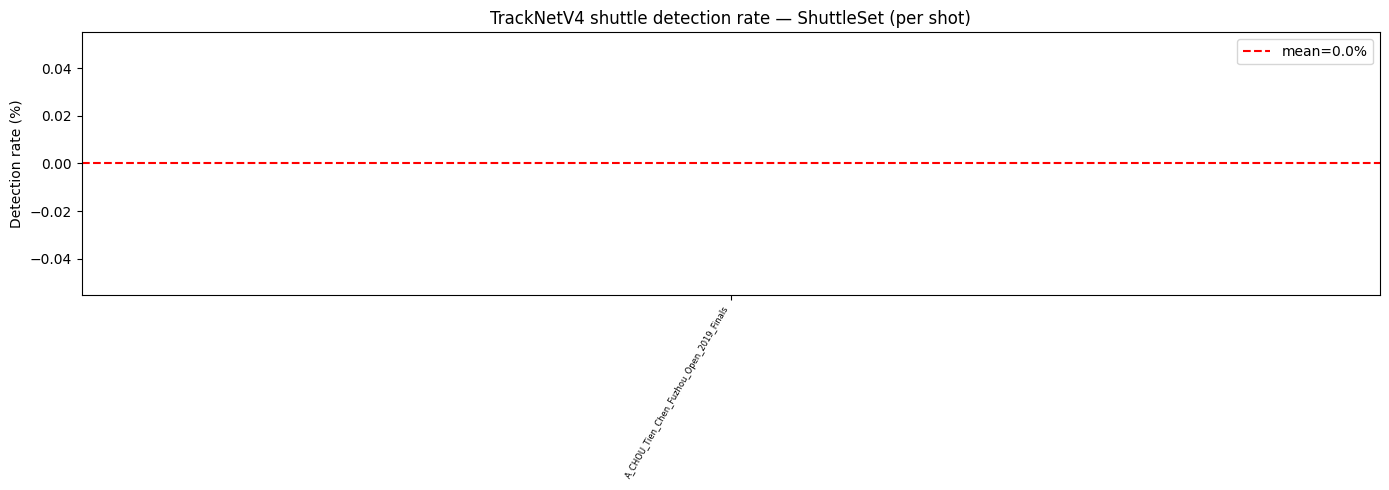

In [23]:
done_files = sorted(SHUTTLE_DIR.glob('*.npy'))
if not done_files:
    print('No files yet.')
else:
    rates = []
    print(f'{"Match":<65} {"Shots":>6} {"Det":>6} {"Rate":>6}')
    print('-' * 85)
    for f in done_files:
        arr = np.load(f)
        n_shots = len(arr)
        n_det   = int(arr[:, 3].sum())
        rate    = n_det / n_shots if n_shots else 0
        rates.append(rate)
        print(f'{f.stem[:65]:<65} {n_shots:>6} {n_det:>6} {rate*100:>5.1f}%')

    print('-' * 85)
    print(f'Mean detection rate: {np.mean(rates)*100:.1f}%')

    # Bar chart
    fig, ax = plt.subplots(figsize=(14, 5))
    labels = [f.stem[-40:] for f in done_files]
    ax.bar(range(len(rates)), [r*100 for r in rates], color='#60a5fa')
    ax.axhline(np.mean(rates)*100, color='red', linestyle='--', label=f'mean={np.mean(rates)*100:.1f}%')
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=60, ha='right', fontsize=6)
    ax.set_ylabel('Detection rate (%)')
    ax.set_title('TrackNetV4 shuttle detection rate — ShuttleSet (per shot)')
    ax.legend()
    plt.tight_layout()
    plt.show()

### 6c. Spatial error vs annotated hit position

ShuttleSet shot metadata includes `hit_x/hit_y` (the shuttle position at the
hit frame) for some shots (many are NaN).  Where both TrackNet and the
annotation are available we compute the Euclidean pixel error and the
normalised error (÷ frame diagonal).

In [24]:
import math

FRAME_DIAG = math.sqrt(IMG_W**2 + IMG_H**2)  # ~2203 px

all_errs = []
for npy_file in SHUTTLE_DIR.glob('*.npy'):
    match_id = npy_file.stem
    arr = np.load(npy_file)
    shots = json.loads((SS_OUTPUTS / f'{match_id}.json').read_text())

    for i, shot in enumerate(shots):
        if i >= len(arr):
            break
        if arr[i, 3] == 0:  # not detected
            continue
        hx, hy = shot.get('hit_x'), shot.get('hit_y')
        if hx is None or hy is None:
            continue
        try:
            hx, hy = float(hx), float(hy)
        except (TypeError, ValueError):
            continue
        if math.isnan(hx) or math.isnan(hy):
            continue
        tx, ty = arr[i, 1], arr[i, 2]
        err = math.sqrt((tx - hx)**2 + (ty - hy)**2)
        all_errs.append(err)

if all_errs:
    arr_errs = np.array(all_errs)
    print(f'Shots with both TrackNet & hit annotation: {len(all_errs)}')
    print(f'Mean error  : {arr_errs.mean():.1f} px  ({arr_errs.mean()/FRAME_DIAG*100:.2f}% of diagonal)')
    print(f'Median error: {np.median(arr_errs):.1f} px')
    print(f'P90 error   : {np.percentile(arr_errs, 90):.1f} px')

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(arr_errs, bins=50, color='#60a5fa', edgecolor='white')
    ax.axvline(arr_errs.mean(), color='red', linestyle='--',
               label=f'mean={arr_errs.mean():.0f} px')
    ax.axvline(np.median(arr_errs), color='orange', linestyle='--',
               label=f'median={np.median(arr_errs):.0f} px')
    ax.set_xlabel('Pixel error vs annotated hit position')
    ax.set_ylabel('Shots')
    ax.set_title('TrackNetV4 spatial error — ShuttleSet')
    ax.legend()
    plt.tight_layout()
    plt.show()
else:
    print('No shots with both TrackNet detection and hit_x/hit_y annotation available.')
    print('(Many ShuttleSet shots only have landing annotations, not hit annotations.)')

No shots with both TrackNet detection and hit_x/hit_y annotation available.
(Many ShuttleSet shots only have landing annotations, not hit annotations.)


## 7. Summary

In [25]:
done_files = sorted(SHUTTLE_DIR.glob('*.npy'))
print(f'Shuttle trajectory files: {len(done_files)} / {len(list(SS_OUTPUTS.glob("*.json")))} matches')

total_shots = total_det = 0
for f in done_files:
    arr = np.load(f)
    n_det = int(arr[:, 3].sum())
    rate  = n_det / len(arr) * 100
    total_shots += len(arr)
    total_det   += n_det
    print(f'  {f.stem[:60]}: shots={len(arr)}, detected={n_det} ({rate:.0f}%)')

if total_shots:
    print(f'\nOverall detection rate: {total_det}/{total_shots} ({100*total_det/total_shots:.1f}%)')
    print(f'Output format: (N_shots, 4)  —  [frame_num, x, y, visible]  @  1920×1080')

Shuttle trajectory files: 1 / 26 matches
  Kento_MOMOTA_CHOU_Tien_Chen_Fuzhou_Open_2019_Finals: shots=1644, detected=0 (0%)

Overall detection rate: 0/1644 (0.0%)
Output format: (N_shots, 4)  —  [frame_num, x, y, visible]  @  1920×1080


In [27]:
## ── Save extracted skeletons to Google Drive (Colab only) ────────────────────
## Run this after extraction to persist results before the session ends.
## Saves to: MyDrive/FineBadminton/shuttleset_skeletons_gdino.zip

if IN_COLAB:
    import shutil, os
    from pathlib import Path

    DRIVE_DIR  = Path('/content/drive/MyDrive/FineBadminton')
    DRIVE_DIR.mkdir(parents=True, exist_ok=True)
    skel_dir   = SS_SKELETONS_GDINO
    out_zip    = DRIVE_DIR / 'shuttleset_shuttles.zip'

    n_files = len(list(skel_dir.rglob('*.npy'))) if skel_dir.exists() else 0
    print(f"Skeletons to archive: {n_files} .npy files from {skel_dir}")

    if n_files == 0:
        print("[WARN] No skeletons found — run extraction first.")
    else:
        print(f"Zipping to {out_zip} ...")
        shutil.make_archive(str(out_zip).replace('.zip', ''), 'zip', skel_dir.parent, skel_dir.name)
        size_mb = out_zip.stat().st_size / 1e6
        print(f"Saved: {out_zip} ({size_mb:.1f} MB, {n_files} skeletons)")
else:
    print("Local run — skeletons already on disk, no Drive save needed")

NameError: name 'SS_SKELETONS_GDINO' is not defined